In [1]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import os, sys
from astropy.io import fits
import healpy as hp
#from decimal import Decimal

#from scipy.interpolate import interp1d
#from scipy.optimize import minimize, shgo
#from scipy.stats import poisson
#from scipy import signal

sys.path.append('..')

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc_file('../notebooks/matplotlibrc')

In [2]:
from utils.data_processing import get_GC_data, downsample

## 1. Cross check

### 1.1 p6v11 is very close to previously gtsrcmaps'ed map

In [3]:
# new
hdul_new = fits.open('../data/exposed_templates/p6v11_irfsv2_ultracleanveto_bestpsf_halfsky1.fits')
z_new = get_GC_data(hdul_new[3], 20, verbose=True)[10]

get_GC_data: l: [700:1100]
get_GC_data: b: [700:1100]


In [4]:
# old
hdul_old = fits.open('/zfs/tslatyer/fermidata/diffusemodel/pass8_573weeks/diffuse_model_map_p6v11_ultracleanveto_bestpsf_joined.fits')
z_old = get_GC_data(hdul_old[0], 20, verbose=True)[10]

get_GC_data: l: [1600:2000]
get_GC_data: b: [700:1100]


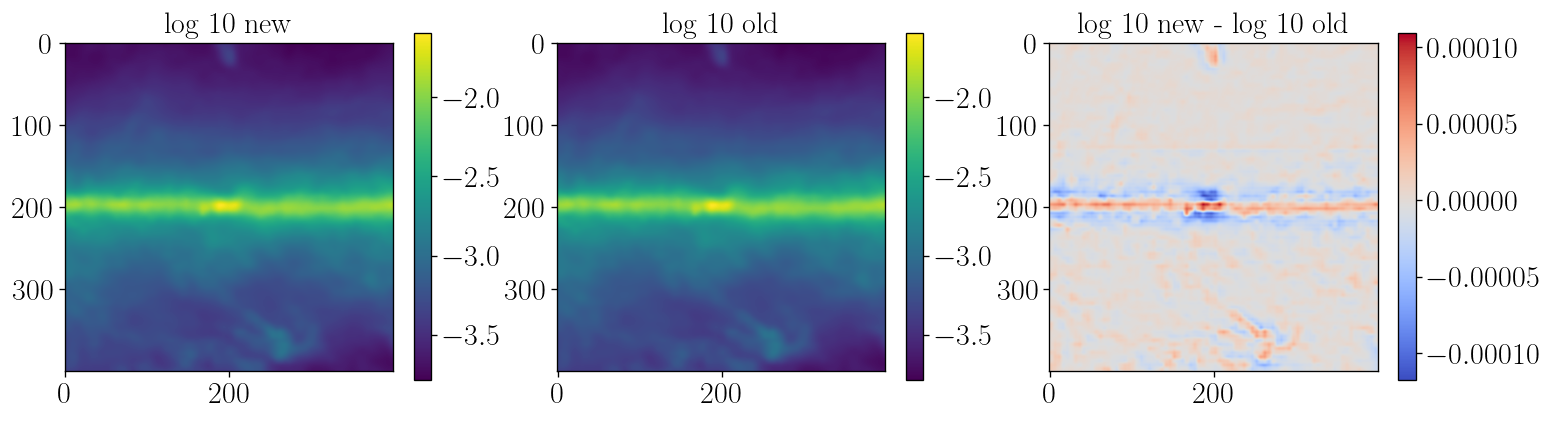

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(15,5))
im0 = axs[0].imshow(np.log10(z_new))
axs[0].set(title='log 10 new')
fig.colorbar(im0, ax=axs[0], shrink=0.75)

im1 = axs[1].imshow(np.log10(z_old))
axs[1].set(title='log 10 old')
fig.colorbar(im1, ax=axs[1], shrink=0.75)

im2 = axs[2].imshow(np.log10(z_new)-np.log10(z_old), cmap='coolwarm')
axs[2].set(title='log 10 new - log 10 old')
fig.colorbar(im2, ax=axs[2], shrink=0.75);

### 1.2 ccwapibrem is identical

In [6]:
# new
hdul_new = fits.open('../data/exposed_templates/ccwapibrem_irfsv2_ultracleanveto_bestpsf_halfsky1.fits')
z_new = get_GC_data(hdul_new[3], 20, verbose=True)[10]

get_GC_data: l: [700:1100]
get_GC_data: b: [700:1100]


In [7]:
# old
hdul_old = fits.open('/zfs/tslatyer/fermidata/diffusemodel/pass8_573weeks/diffuse_model_map_ccwapibrem_ultracleanveto_bestpsf_joined.fits')
z_old = get_GC_data(hdul_old[0], 20, verbose=True)[10]

get_GC_data: l: [1600:2000]
get_GC_data: b: [700:1100]


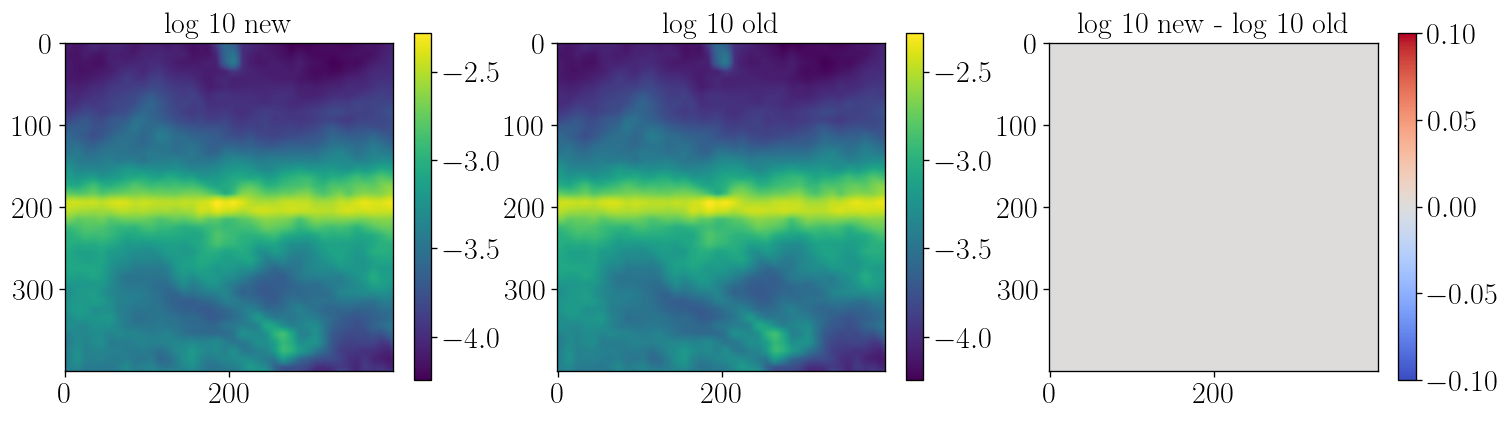

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(15,5))
im0 = axs[0].imshow(np.log10(z_new))
axs[0].set(title='log 10 new')
fig.colorbar(im0, ax=axs[0], shrink=0.75)

im1 = axs[1].imshow(np.log10(z_old))
axs[1].set(title='log 10 old')
fig.colorbar(im1, ax=axs[1], shrink=0.75)

im2 = axs[2].imshow(np.log10(z_new)-np.log10(z_old), cmap='coolwarm')
axs[2].set(title='log 10 new - log 10 old')
fig.colorbar(im2, ax=axs[2], shrink=0.75);

In [9]:
np.all(z_new==z_old)

True

## 2. gtsrcmaps input fits format
exposure RA must go from 180 to -180 (previously 90 to -270) \
template files:

In [7]:
hdul = fits.open('/zfs/nrodd/GalPropMap/Models/ccwapibrem.fit')

In [8]:
len(hdul)

2

In [9]:
hdul[0].header

SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                  -32 / number of bits per data pixel                  
NAXIS   =                    3 / number of data axes                            
NAXIS1  =                  360 / length of data axis 1                          
NAXIS2  =                  180 / length of data axis 2                          
NAXIS3  =                   38 / length of data axis 3                          
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
FLUX    =     1.71683910074994 / photon flux (m^-2 s^-1)                        
CRVAL1  =                 180. / updated ref point                              
CDELT1  =                   1. / step size                                      
CRPIX1  =                180

In [10]:
hdul[0].data.shape

(38, 180, 360)

In [11]:
np.mean(hdul[0].data)

2.7891861e-08

In [12]:
hdul[1].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / 8-bit bytes                                    
NAXIS   =                    2 / 2-dimensional binary table                     
NAXIS1  =                    8 / width of table in bytes                        
NAXIS2  =                   38 / number of rows in table                        
PCOUNT  =                    0 / size of special data area                      
GCOUNT  =                    1 / one data group (required keyword)              
TFIELDS =                    1 / number of fields in each row                   
COMMENT                                                                         
COMMENT  *** End of mandatory fields ***                                        
COMMENT                                                                         
COMMENT                                                                         
COMMENT  *** Column names **

### 2.1 CZMS

In [92]:
hdul_czms = fits.open('../data/external/CZMS/GALACTIC_DIFFUSE_EMISSION_MAPS_0p25deg/bremss_0w_Map_flux_E_50-814008_MeV_InnerGalaxy_60x60.fits')

In [93]:
hdul_ccw = fits.open('ccw_base.fits')

In [94]:
hdul_ccw[0].header

SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                  -32 / number of bits per data pixel                  
NAXIS   =                    3 / number of data axes                            
NAXIS1  =                  360 / length of data axis 1                          
NAXIS2  =                  180 / length of data axis 2                          
NAXIS3  =                   38 / length of data axis 3                          
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
FLUX    =                   -1 / photon flux (m^-2 s^-1)                        
CRVAL1  =                   -1 / updated ref point                              
CDELT1  =                   -1 / step size                                      
CRPIX1  =                   

In [95]:
np.mean(hdul_ccw[0].data)

2.7891861e-08

In [98]:
# change and save
hdul_ccw[0].data = hdul_czms[0].data
hdul_ccw[0].header['NAXIS1'] = 240
hdul_ccw[0].header['NAXIS2'] = 240
hdul_ccw[0].header['CRVAL1'] = 0.
hdul_ccw[0].header['CDELT1'] = 0.25
hdul_ccw[0].header['CRPIX1'] = 120.5
hdul_ccw[0].header['CRVAL2'] = 0.
hdul_ccw[0].header['CDELT2'] = 0.25
hdul_ccw[0].header['CRPIX2'] = 120.5
hdul_ccw[0].header['FLUX'] = -1
hdul_ccw.writeto('ccw_base_copy_test.fits', overwrite=True)

In [100]:
hdul_test = fits.open('ccw_base_copy_test.fits')

### 2.1.3 result

In [5]:
hdul_exposed = fits.open('../data/exposed_templates/test_CZMS_ultracleanveto_bestpsf_halfsky1.fits')

In [8]:
z = get_GC_data(hdul_exposed[3], 30, verbose=True)[10]

get_GC_data: l: [600:1200]
get_GC_data: b: [600:1200]


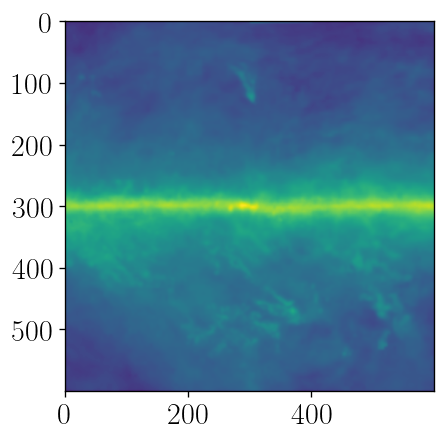

In [9]:
plt.imshow(np.log(z))

### 2.1.1 orientation

In [81]:
z_czms = hdul_czms[0].data[10].copy()
z_czms[10:20, 30:35] = 0.001
#z_ccw = get_GC_data(hdul_ccw[0], 30, verbose=True)[10]
z_ccw = np.take(hdul_ccw[0].data[10, 60:120, :], range(-30,30), mode='wrap', axis=-1)

In [82]:
z_ccw.shape

(60, 60)

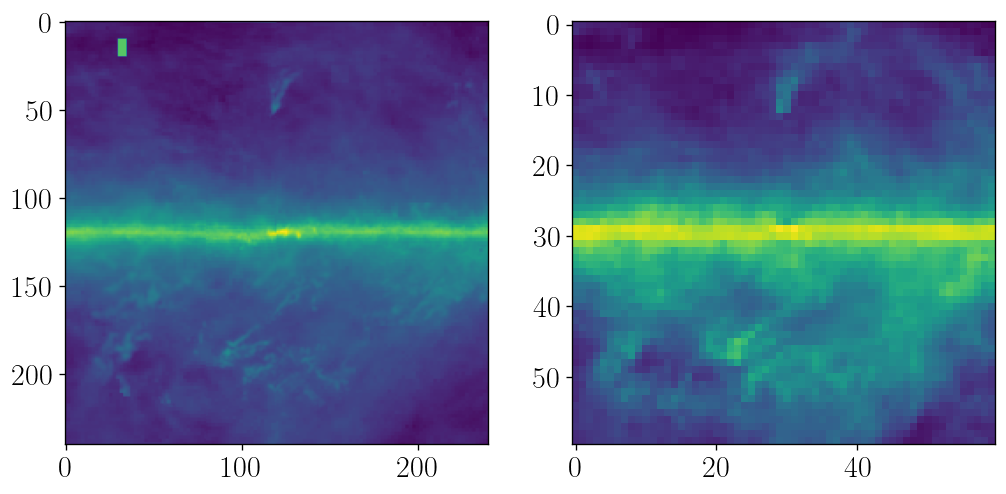

In [83]:
fig, axs = plt.subplots(1, 2, figsize=(10,5))
axs[0].imshow(np.log10(z))
axs[1].imshow(np.log10(z_ccw))

### 2.1.2 energies

In [26]:
hdul_ccw = fits.open('ccw_base.fits')

In [21]:
# below is Siddharth's code for CZMS's energy
# seems okay to borrow CCW's energy
e_bins = np.logspace(np.log10(43.8587), np.log10(714027.0), 38)
e_bins_widths = (e_bins[1:] - e_bins[:-1])
e_bins_centers = (e_bins[1:] + e_bins[:-1]) / 2

In [24]:
e_bins_centers

array([5.04299746e+01, 6.55416496e+01, 8.51816378e+01, 1.10706878e+02,
       1.43880925e+02, 1.86995795e+02, 2.43030320e+02, 3.15855961e+02,
       4.10504286e+02, 5.33514607e+02, 6.93385783e+02, 9.01163413e+02,
       1.17120298e+03, 1.52216169e+03, 1.97828750e+03, 2.57109441e+03,
       3.34153984e+03, 4.34285432e+03, 5.64421931e+03, 7.33554690e+03,
       9.53369198e+03, 1.23905258e+04, 1.61034286e+04, 2.09289274e+04,
       2.72004188e+04, 3.53512039e+04, 4.59444256e+04, 5.97119763e+04,
       7.76050644e+04, 1.00859935e+05, 1.31083280e+05, 1.70363251e+05,
       2.21413724e+05, 2.87761809e+05, 3.73991536e+05, 4.86060570e+05,
       6.31711831e+05])

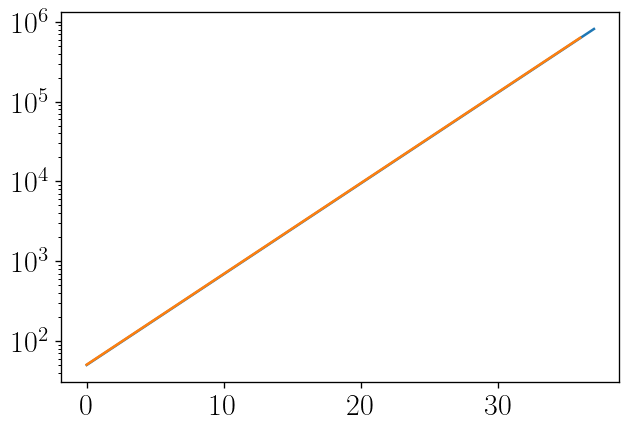

In [23]:
plt.plot(hdul_ccw[1].data['ENERGY'])
plt.plot(e_bins_centers)
plt.yscale('log')

In [26]:
hdul_ccw = fits.open('ccw_base.fits')

In [28]:
hdul_ccw[0].header['NAXIS1'] = -1
hdul_ccw[0].header['NAXIS2'] = -1
hdul_ccw[0].header['CRVAL1'] = -1
hdul_ccw[0].header['CDELT1'] = -1
hdul_ccw[0].header['CRPIX1'] = -1
hdul_ccw[0].header['CRVAL2'] = -1
hdul_ccw[0].header['CDELT2'] = -1
hdul_ccw[0].header['CRPIX2'] = -1
hdul_ccw[0].header['FLUX'] = -1

In [29]:
hdul_ccw[0].header

SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                  -32 / number of bits per data pixel                  
NAXIS   =                    3 / number of data axes                            
NAXIS1  =                   -1 / length of data axis 1                          
NAXIS2  =                   -1 / length of data axis 2                          
NAXIS3  =                   38 / length of data axis 3                          
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
FLUX    =                   -1 / photon flux (m^-2 s^-1)                        
CRVAL1  =                   -1 / updated ref point                              
CDELT1  =                   -1 / step size                                      
CRPIX1  =                   

In [30]:
hdul_ccw.writeto('ccw_base.fits', overwrite=True)

## A. Plot

In [3]:
hdul = fits.open('../data/exposed_templates/test/test_ultracleanveto_bestpsf_halfsky1.fits')

In [4]:
z = get_GC_data(hdul[3], 20, verbose=True)[10]

get_GC_data: l: [700:1100]
get_GC_data: b: [700:1100]


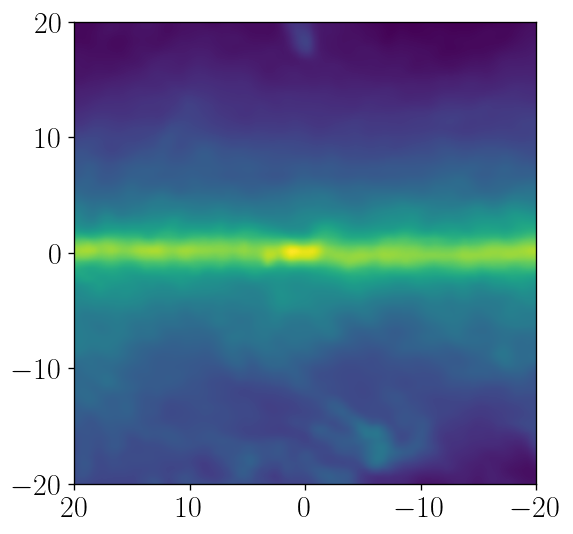

In [7]:
fig, ax = plt.subplots(figsize=(5,5))
ax.imshow(np.log10(z), extent=(20,-20,-20,20))